# VHI Drought Analysis - Ukraine Dataset

## Dataset Description

**Region:** Ukraine — 27 administrative oblasts (regions 1 to 27)
**Time Period:** 1982 to 2023 (weekly observations)
**Total Records:** 58,968 rows (27 regions x 42 years x 52 weeks)

### Variables

| Column | Description |
|--------|-------------|
| Year   | Year of observation (1982–2023) |
| Week   | Week number (1–52) |
| SMN    | Soil Moisture minimum |
| SMT    | Soil Moisture mean |
| VCI    | Vegetation Condition Index (0–100) |
| TCI    | Temperature Condition Index (0–100) |
| VHI    | Vegetation Health Index = 0.5*VCI + 0.5*TCI |
| Region | Oblast number (1–27) |

### Target Variable: VHI_Class

| VHI Range     | Class               |
|---------------|---------------------|
| VHI < 10      | Extreme Drought     |
| 10 <= VHI < 20 | Severe Drought      |
| 20 <= VHI < 35 | Mild Drought        |
| VHI >= 35     | No Drought Condition |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, silhouette_score, ConfusionMatrixDisplay)


## 1. Load Dataset

In [2]:
df = pd.read_csv('dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (58968, 8)


,Year,Week,SMN,SMT,VCI,TCI,VHI,Region
0,1982,1,3.69,3.03,39.74,35.06,37.40,1
1,1982,2,0.38,4.34,30.03,34.85,32.44,1
2,1982,3,0.20,4.85,58.72,47.98,53.35,1
3,1982,4,0.99,1.00,29.70,46.56,38.13,1
4,1982,5,2.22,1.53,42.27,18.52,30.39,1


## 2. Exploratory Data Analysis (EDA)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58968 entries, 0 to 58967
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    58968 non-null  int64  
 1   Week    58968 non-null  int64  
 2   SMN     58968 non-null  float64
 3   SMT     58968 non-null  float64
 4   VCI     58968 non-null  float64
 5   TCI     58968 non-null  float64
 6   VHI     58968 non-null  float64
 7   Region  58968 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 3.6 MB


In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Missing values:
Year      0
Week      0
SMN       0
SMT       0
VCI       0
TCI       0
VHI       0
Region    0
dtype: int64

Duplicates: 0


In [5]:
df.describe()


,Year,Week,SMN,SMT,VCI,TCI,VHI,Region
count,58968.000000,58968.000000,58968.000000,58968.000000,58968.000000,58968.000000,58968.000000,58968.000000
mean,2002.500000,26.500000,2.555012,2.542408,50.088892,49.976021,50.032479,14.000000
std,12.121021,15.008458,1.415682,1.412669,20.517472,16.013622,15.640975,7.788947
min,1982.000000,1.000000,0.100000,0.100000,0.000000,0.000000,2.970000,1.000000
25%,1992.000000,13.750000,1.330000,1.310000,35.310000,38.630000,38.100000,7.000000
50%,2002.500000,26.500000,2.550000,2.540000,50.115000,49.920000,50.050000,14.000000
75%,2013.000000,39.250000,3.780000,3.760000,64.850000,61.380000,62.040000,21.000000
max,2023.000000,52.000000,5.000000,5.000000,100.000000,100.000000,99.490000,27.000000


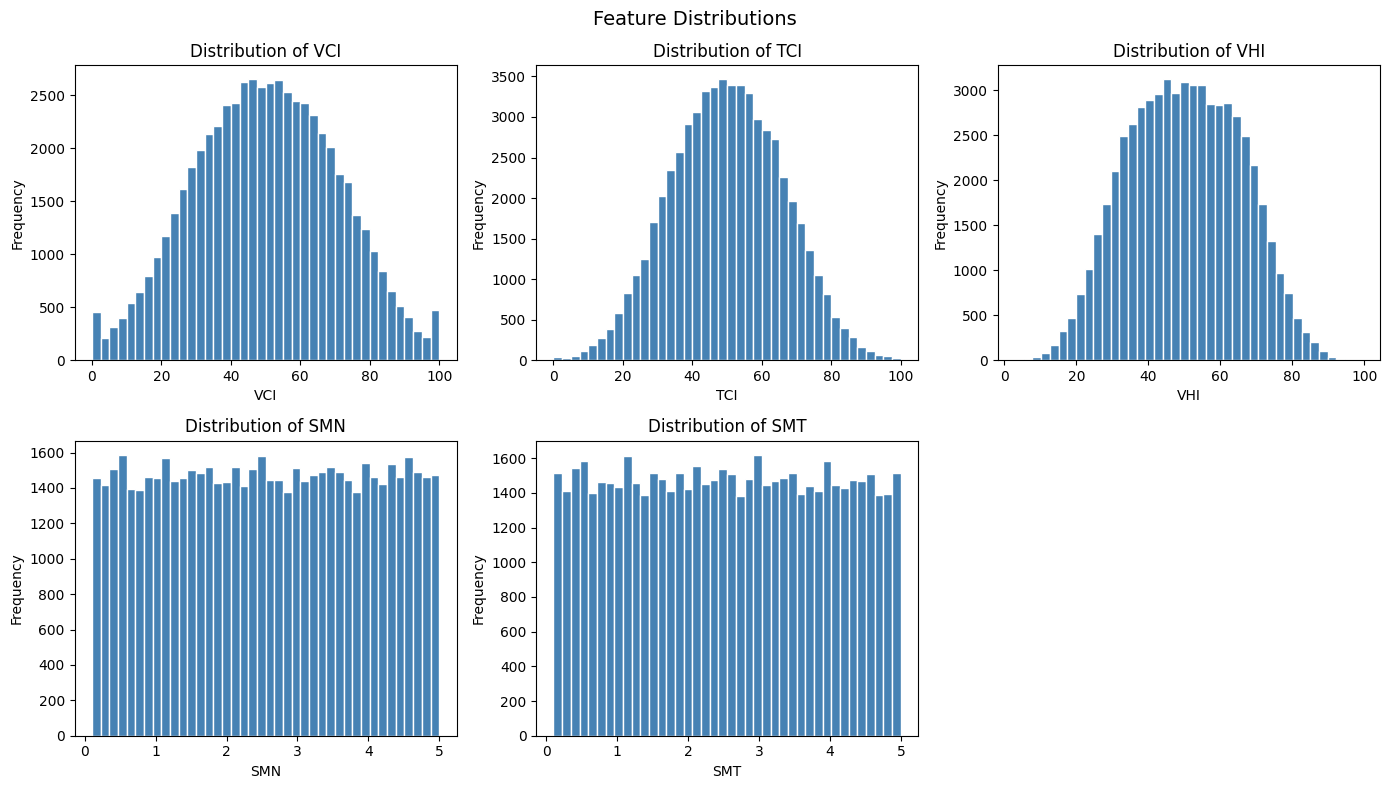

In [6]:
cols = ['VCI', 'TCI', 'VHI', 'SMN', 'SMT']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title('Distribution of ' + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[5].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()


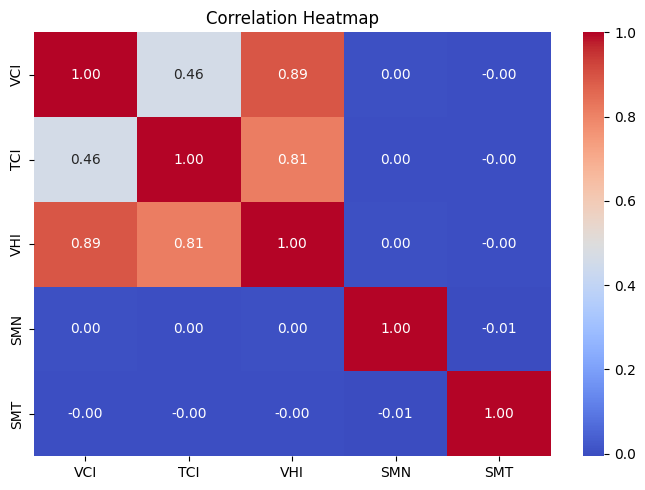

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['VCI', 'TCI', 'VHI', 'SMN', 'SMT']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 3. Create Target Variable (VHI_Class)

In [25]:
def label_vhi(val):
    if val < 10:
        return 'Extreme Drought'
    elif val < 20:
        return 'Severe Drought'
    elif val < 35:
        return 'Mild Drought'
    else:
        return 'No Drought Condition'

df['VHI_Class'] = df['VHI'].apply(label_vhi)
print(df['VHI_Class'].value_counts())



VHI_Class
No Drought Condition    47702
Mild Drought            10124
Severe Drought           1091
Extreme Drought            51
Name: count, dtype: int64


## 4. Preprocessing

In [10]:
features = ['Year', 'Week', 'SMN', 'SMT', 'VCI', 'TCI', 'Region']
X = df[features]
y_labels = df['VHI_Class']

encoder = LabelEncoder()
y = encoder.fit_transform(y_labels)
print("Classes:", list(encoder.classes_))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Classes: ['Extreme Drought', 'Mild Drought', 'No Drought Condition', 'Severe Drought']
Train size: 47174
Test size : 11794


## 5. KNN Classifier

In [12]:
acc_list = []
for k in range(1, 16):
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model.fit(X_train, y_train)
    acc_list.append(accuracy_score(y_test, model.predict(X_test)))


best_k = acc_list.index(max(acc_list)) + 1
print("Best K:", best_k, "| Accuracy:", round(max(acc_list), 4))


Best K: 13 | Accuracy: 0.9614


                      precision    recall  f1-score   support

     Extreme Drought       0.00      0.00      0.00        10
        Mild Drought       0.89      0.90      0.89      2025
No Drought Condition       0.98      0.99      0.98      9541
      Severe Drought       0.86      0.32      0.47       218

            accuracy                           0.96     11794
           macro avg       0.68      0.55      0.59     11794
        weighted avg       0.96      0.96      0.96     11794



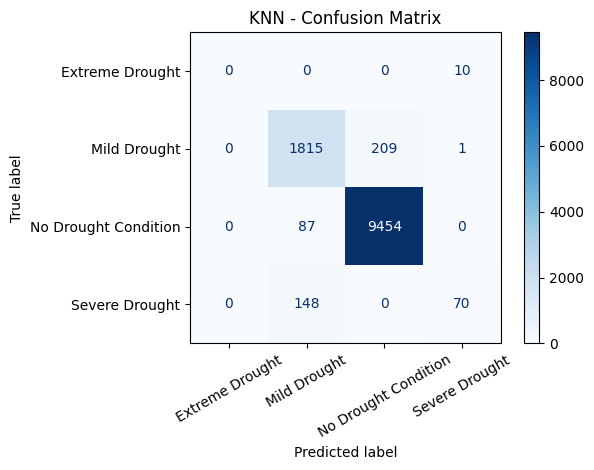

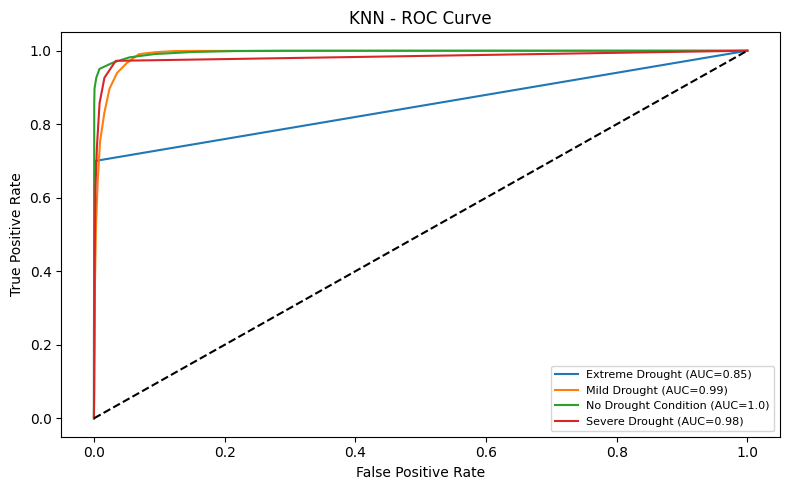

In [13]:
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(classification_report(y_test, y_pred_knn, target_names=encoder.classes_))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=encoder.classes_).plot(cmap='Blues')
plt.title('KNN - Confusion Matrix')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

y_test_bin = label_binarize(y_test, classes=range(len(encoder.classes_)))
y_prob_knn = knn.predict_proba(X_test)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    plt.plot(fpr, tpr, label=cls + ' (AUC=' + str(round(auc(fpr, tpr), 2)) + ')')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('KNN - ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6. Naive Bayes Classifier

In [24]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print(classification_report(y_test, y_pred_nb, target_names=encoder.classes_))

cm_nb = confusion_matrix(y_test, y_pred_nb)



                      precision    recall  f1-score   support

     Extreme Drought       0.00      0.00      0.00        10
        Mild Drought       0.76      0.95      0.85      2025
No Drought Condition       0.99      0.96      0.97      9541
      Severe Drought       0.82      0.21      0.34       218

            accuracy                           0.94     11794
           macro avg       0.64      0.53      0.54     11794
        weighted avg       0.95      0.94      0.94     11794



## 7. K-Means Clustering

K=2 | Inertia=29288 | Silhouette=0.1667
K=3 | Inertia=26015 | Silhouette=0.1608
K=4 | Inertia=24039 | Silhouette=0.1442
K=5 | Inertia=22683 | Silhouette=0.1365
K=6 | Inertia=21507 | Silhouette=0.1272
K=7 | Inertia=20550 | Silhouette=0.1267
K=8 | Inertia=19723 | Silhouette=0.1260
K=9 | Inertia=19046 | Silhouette=0.1238
K=10 | Inertia=18423 | Silhouette=0.1224


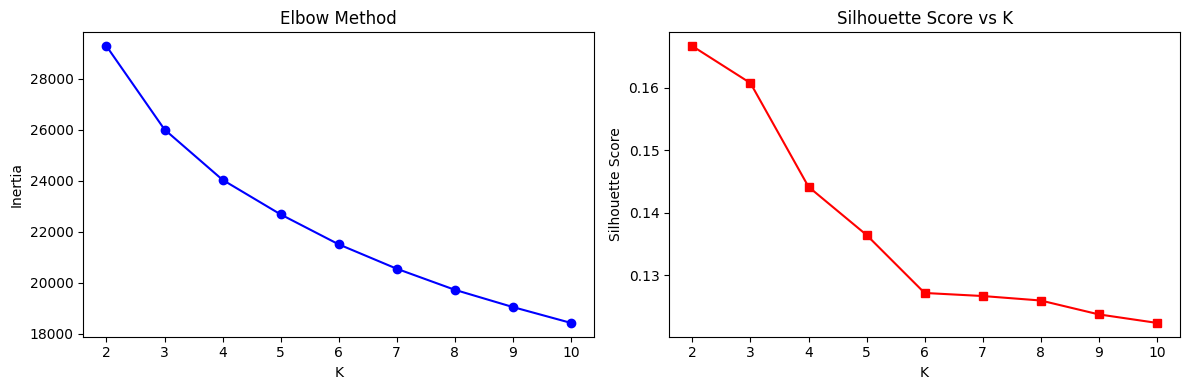


Optimal K: 2


In [15]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 5000, replace=False)
X_sample = X_scaled[sample_idx]

inertia_list = []
sil_list = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_sample)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_sample, km_labels))
    print(f"K={k} | Inertia={km.inertia_:.0f} | Silhouette={sil_list[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 11), inertia_list, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(range(2, 11), sil_list, 'rs-')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k_means = sil_list.index(max(sil_list)) + 2
print("\nOptimal K:", best_k_means)


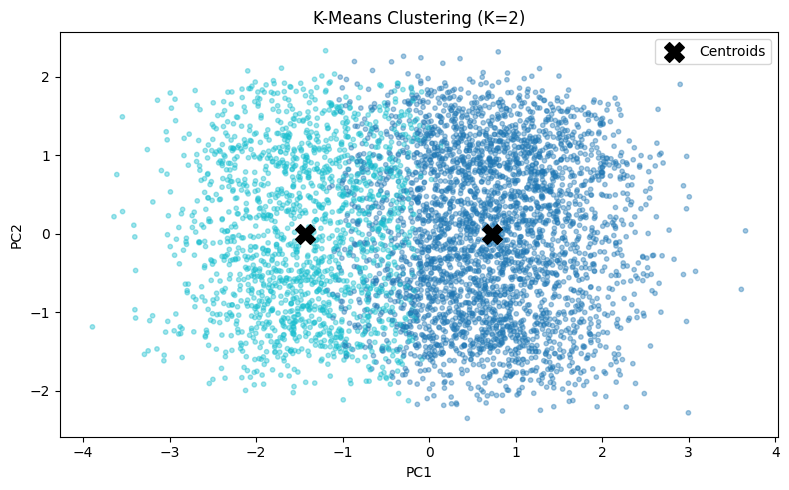

K-Means Silhouette Score: 0.1667


In [16]:
km_final = KMeans(n_clusters=best_k_means, random_state=42, n_init=10)
km_cluster_labels = km_final.fit_predict(X_sample)

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_sample)

plt.figure(figsize=(8, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=km_cluster_labels, cmap='tab10', alpha=0.4, s=10)
centers = pca_2d.transform(km_final.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering (K=' + str(best_k_means) + ')')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

km_sil = silhouette_score(X_sample, km_cluster_labels)
print("K-Means Silhouette Score:", round(km_sil, 4))


## 8. Hierarchical Clustering (Agglomerative)

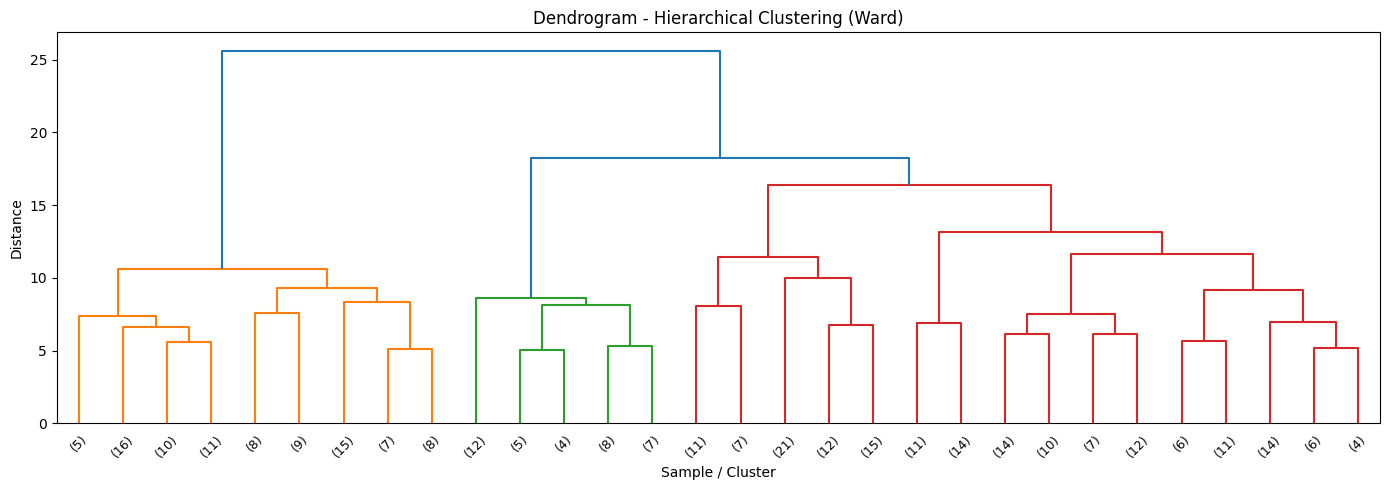

In [17]:
X_dend = X_sample[:300]
Z = linkage(X_dend, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=9)
plt.title('Dendrogram - Hierarchical Clustering (Ward)')
plt.xlabel('Sample / Cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


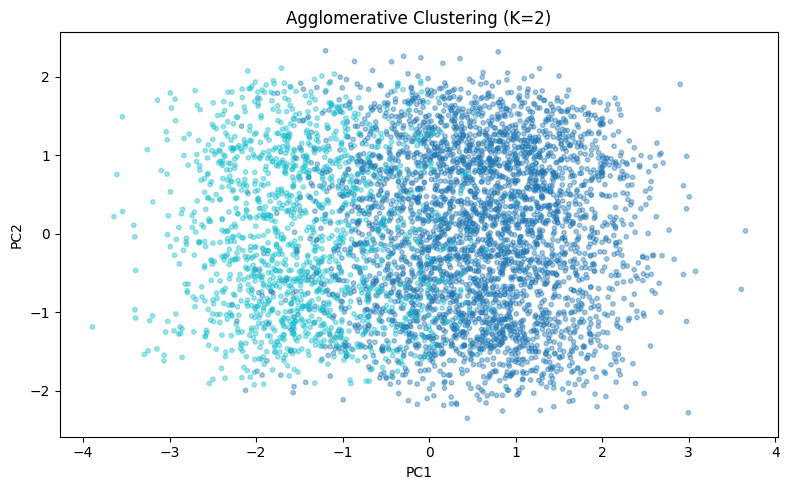

Agglomerative Silhouette Score: 0.1442


In [18]:
agg = AgglomerativeClustering(n_clusters=best_k_means, linkage='ward')
agg_cluster_labels = agg.fit_predict(X_sample)

plt.figure(figsize=(8, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=agg_cluster_labels, cmap='tab10', alpha=0.4, s=10)
plt.title('Agglomerative Clustering (K=' + str(best_k_means) + ')')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

agg_sil = silhouette_score(X_sample, agg_cluster_labels)
print("Agglomerative Silhouette Score:", round(agg_sil, 4))


In [19]:
print("Clustering Comparison (Silhouette Score)")
print("K-Means        :", round(km_sil, 4))
print("Agglomerative  :", round(agg_sil, 4))


Clustering Comparison (Silhouette Score)
K-Means        : 0.1667
Agglomerative  : 0.1442


## 9. PCA

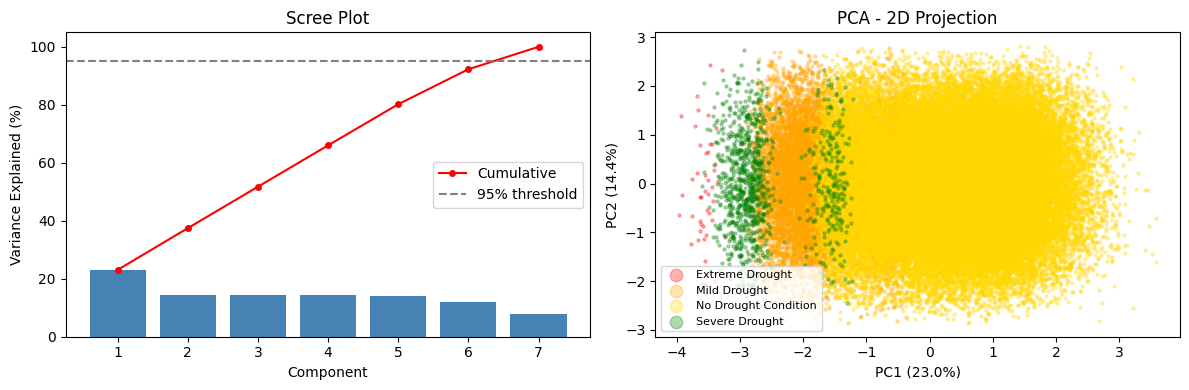

Components for 95% variance: 7


In [20]:
pca = PCA()
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained) + 1), explained * 100, color='steelblue')
axes[0].plot(range(1, len(explained) + 1), cumulative * 100, 'r-o', markersize=4, label='Cumulative')
axes[0].axhline(95, color='gray', linestyle='--', label='95% threshold')
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].legend()

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
colors = ['red', 'orange', 'gold', 'green']
for i, cls in enumerate(encoder.classes_):
    mask = y == i
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],c=colors[i], label=cls, alpha=0.3, s=5)
axes[1].set_title('PCA - 2D Projection')
axes[1].set_xlabel('PC1 (' + str(round(pca2.explained_variance_ratio_[0]*100, 1)) + '%)')
axes[1].set_ylabel('PC2 (' + str(round(pca2.explained_variance_ratio_[1]*100, 1)) + '%)')
axes[1].legend(markerscale=4, fontsize=8)

plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95)) + 1
print("Components for 95% variance:", n_components_95)
